In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
# WAJIB DI PALING ATAS: Memaksa penggunaan Keras 2 (Legacy) agar kompatibel dengan Hugging Face
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adilshamim8/student-performance-and-learning-style/student_performance.csv
/kaggle/input/datasets/ziya07/personalized-educational-dataset/student_education_dataset.csv
/kaggle/input/datasets/ridwanadisuryawidodo/slangword/englishslang.csv
/kaggle/input/datasets/ridwanadisuryawidodo/data-science-cleaned-data/master_vak.csv
/kaggle/input/datasets/ridwanadisuryawidodo/data-science-cleaned-data/final_dataset_cleaned.csv
/kaggle/input/datasets/zeyadkhalid/learning-style-vak/dataset.csv


# Start of Notebook
Disini akan dibuat analysis Sentimen menggunakan pendekatan Functional API untuk memprediksi gaya belajar. dataset yang digunakan ada 3 ditambah hasil test nanti. 

In [3]:
# library
import pandas as pd

In [4]:
# Dataset
dataset_1 = pd.read_csv("/kaggle/input/datasets/ziya07/personalized-educational-dataset/student_education_dataset.csv")
dataset_2 = pd.read_csv("/kaggle/input/datasets/zeyadkhalid/learning-style-vak/dataset.csv")
dataset_3 = pd.read_csv("/kaggle/input/datasets/adilshamim8/student-performance-and-learning-style/student_performance.csv")

Disini ada 3 Dataset dan kita akan melakukan Cleaning dan mempertahankan variabel yang menjadi indikator
* Indikator Visual : (Edutech (3), DeviceUsage(1) , Resources (3))
* Indikator Auditory : (Discussion (3) , CourseParticipation (1), EmotionEngagement(1))
* Indikator Kinestetik : (physicalActivity (1), Extracuricullar (3))

In [5]:
# Cleaning Dataset
df_1 = dataset_1.drop(columns=["StudentID", "AcademicScore", "AttendanceRate", "FeedbackScore", "StudentPerformance"])
df_2 = dataset_2.copy()
df_3 = dataset_3.drop(columns=["StudyHours", "Attendance", "Motivation", "Internet", "Gender", "Age", "OnlineCourses", "AssignmentCompletion", "ExamScore", "StressLevel", "FinalGrade"])

In [6]:
# Konversi dan standarisasi value
# df_1
df_1['LearningStyle'] = df_1['LearningStyle'].str.strip().str.capitalize()
# df_3
for index, row in df_3.iterrows():
    if row["LearningStyle"] == 0:
        df_3.at[index, "LearningStyle"] = "Visual"
    elif row["LearningStyle"] == 1:
        df_3.at[index, "LearningStyle"] = "Auditory"
    elif row["LearningStyle"] == 2:
        df_3.at[index, "LearningStyle"] = "Kinesthetic"
    else:
        df_3.at[index, "LearningStyle"] = "Visual"

/tmp/ipykernel_57/680608199.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Kinesthetic' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_3.at[index, "LearningStyle"] = "Kinesthetic"


## Melakukan Standarisasi Label LearningStyle
dikarenakan Kolom LearningStyle merupakan inputan, kita ingin membuat Kolom ini menjadi kolom dependen menggunakan indikator yang telah ditentukan sebelumnya

In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
df_1n = df_1.copy().drop(columns="LearningStyle")
df_3n = df_3.copy().drop(columns="LearningStyle")
visual_cols = ['EduTech', 'DeviceUsage', 'Resources']
auditory_cols = ['Discussions', 'CourseParticipation', 'EmotionEngagement']
kinesthetic_cols = ['PhysicalActivity', 'Extracurricular']

In [8]:
scaler = MinMaxScaler()
df_1n[df_1n.columns] = scaler.fit_transform(df_1n[df_1n.columns])
df_1n

,CourseParticipation,PhysicalActivity,EmotionEngagement,DeviceUsage
0,0.653061,0.939892,0.326916,1.000000
1,0.428571,0.066920,0.892032,0.862069
2,0.408163,0.765778,0.083265,0.034483
3,0.102041,0.393108,0.808855,0.862069
4,0.102041,0.139651,0.863187,0.103448
...,...,...,...,...
995,0.836735,0.540573,0.125507,0.310345
996,0.877551,0.987978,0.026597,0.275862
997,0.979592,0.072731,0.623708,0.413793
998,0.795918,0.363053,0.808421,0.206897


In [9]:
df_3n[df_3n.columns] = scaler.fit_transform(df_3n[df_3n.columns])
df_3n

,Resources,Extracurricular,Discussions,EduTech
0,0.5,0.0,1.0,0.0
1,0.5,0.0,0.0,0.0
2,0.5,0.0,0.0,1.0
3,0.5,1.0,1.0,0.0
4,0.5,1.0,0.0,0.0
...,...,...,...,...
13998,0.0,1.0,1.0,1.0
13999,0.0,1.0,1.0,1.0
14000,1.0,0.0,1.0,0.0
14001,1.0,0.0,0.0,1.0


## Slicing dengan melihat ukuran VAK
tujuannya agar bobot masing-masing VAK tetap proposional

In [10]:
df_dumb_1 = pd.DataFrame(df_1["LearningStyle"])
df_dumb_1["LearningStyle_1"] = df_dumb_1["LearningStyle"]
df_dumb_3 = pd.DataFrame(df_3["LearningStyle"])
df_dumb_3["LearningStyle_3"] = df_dumb_3["LearningStyle"]

In [11]:
import pandas as pd

# 1. Pastikan kita tahu label untuk setiap baris
# Kita gabungkan sementara fitur dan label agar saat di-shuffle/sample tidak terpisah
df_1_full = pd.concat([df_1n, df_dumb_1["LearningStyle_1"]], axis=1)
df_3_full = pd.concat([df_3n, df_dumb_3["LearningStyle_3"]], axis=1)

# 2. Ambil semua data dari Dataset 1 (karena jumlahnya lebih sedikit, yaitu 1000)
# Dan kita urutkan agar rapi: Auditory -> Kinesthetic -> Visual
df_1_sorted = df_1_full.sort_values("LearningStyle_1").reset_index(drop=True)

# 3. Lakukan Slicing Proporsional pada Dataset 3
df_3_sampled_list = []

# Kita ambil sampel dari Dataset 3 sesuai jumlah label yang ada di Dataset 1
for label in ['Auditory', 'Kinesthetic', 'Visual']:
    # Hitung berapa banyak label ini di Dataset 1
    count_needed = len(df_1_sorted[df_1_sorted["LearningStyle_1"] == label])
    
    # Ambil sampel dari Dataset 3 dengan jumlah yang sama
    sampled_sub = df_3_full[df_3_full["LearningStyle_3"] == label].sample(n=count_needed, random_state=42)
    df_3_sampled_list.append(sampled_sub)

# Gabungkan hasil sampling Dataset 3 dan urutkan agar sama dengan Dataset 1
df_3_sorted = pd.concat(df_3_sampled_list).sort_values("LearningStyle_3").reset_index(drop=True)

# 4. Pecah kembali ke variabel a, b, c, d sesuai permintaanmu
a = df_1_sorted.drop(columns=["LearningStyle_1"])
b = df_3_sorted.drop(columns=["LearningStyle_3"])
c = df_1_sorted["LearningStyle_1"]
d = df_3_sorted["LearningStyle_3"]

# 5. Gabungkan secara horizontal
# Sekarang baris ke-0 di 'a' dijamin memiliki label yang sama dengan baris ke-0 di 'b'
df_side = pd.concat([a, b, c, d], axis=1)

print("Statistik Label Setelah Sinkronisasi:")
print(df_side["LearningStyle_1"].value_counts())

Statistik Label Setelah Sinkronisasi:
LearningStyle_1
Kinesthetic    351
Visual         325
Auditory       324
Name: count, dtype: int64


In [12]:
df_side

,CourseParticipation,PhysicalActivity,EmotionEngagement,DeviceUsage,Resources,Extracurricular,Discussions,EduTech,LearningStyle_1,LearningStyle_3
0,0.000000,0.812863,0.743023,0.310345,0.5,1.0,1.0,1.0,Auditory,Auditory
1,0.489796,0.465438,0.875021,0.827586,0.5,1.0,0.0,1.0,Auditory,Auditory
2,0.306122,0.003606,0.905118,0.448276,0.0,1.0,0.0,1.0,Auditory,Auditory
3,0.591837,0.672611,0.828390,0.275862,0.0,1.0,0.0,0.0,Auditory,Auditory
4,0.571429,0.216790,0.969527,0.551724,0.5,0.0,1.0,0.0,Auditory,Auditory
...,...,...,...,...,...,...,...,...,...,...
995,0.510204,0.835704,0.870535,0.827586,0.5,0.0,0.0,0.0,Visual,Visual
996,0.326531,0.692446,0.934456,0.241379,1.0,0.0,0.0,1.0,Visual,Visual
997,0.020408,0.764576,0.558661,0.344828,0.5,0.0,1.0,1.0,Visual,Visual
998,0.918367,0.533160,0.257845,0.862069,0.5,1.0,1.0,1.0,Visual,Visual


## Fungsi automate_label_correction
Fungsi ini bertujuan untuk melakukan pengecekan apakah label layak digunakan karena ada perbedaan pemberian label yang disebabkan perbedaan indikator yang digunakan serta kolom LearningStyle yang merupakan kolom independen. fungsi ini akan memberikan flag untuk selanjutnya digunakan pada proses weighting

In [13]:
def automate_label_correction(df):
    processed_df = df.copy()
    processed_df['Score_Visual'] = processed_df[visual_cols].sum(axis=1)
    processed_df['Score_Auditory'] = processed_df[auditory_cols].sum(axis=1)
    processed_df['Score_Kinesthetic'] = processed_df[kinesthetic_cols].sum(axis=1)

    # 1) Hitung calculated style (tanpa side-effect)
    def calc_style(row):
        scores = {
            'Visual': row['Score_Visual'],
            'Auditory': row['Score_Auditory'],
            'Kinesthetic': row['Score_Kinesthetic']
        }
        return max(scores, key=scores.get)

    processed_df['Calculated_Style'] = processed_df.apply(calc_style, axis=1)
    processed_df['Corrected_LearningStyle'] = processed_df['Calculated_Style']
    processed_df['Is_Changed'] = processed_df['LearningStyle_1'] != processed_df['Corrected_LearningStyle']

    final_df = processed_df.drop(columns=['Score_Visual', 'Score_Auditory', 'Score_Kinesthetic', 'Calculated_Style'])
    return final_df

# Contoh penggunaan:
df_final_13 = automate_label_correction(df_side)
df_final_13 = df_final_13.sort_values('Corrected_LearningStyle').reset_index(drop=True)
df_final_13

,CourseParticipation,PhysicalActivity,EmotionEngagement,DeviceUsage,Resources,Extracurricular,Discussions,EduTech,LearningStyle_1,LearningStyle_3,Corrected_LearningStyle,Is_Changed
0,0.081633,0.682829,0.883559,0.655172,0.0,1.0,1.0,1.0,Kinesthetic,Kinesthetic,Auditory,True
1,0.612245,0.188339,0.404729,0.448276,0.5,1.0,1.0,1.0,Kinesthetic,Kinesthetic,Auditory,True
2,0.836735,0.122821,0.600517,0.241379,0.0,1.0,1.0,1.0,Visual,Visual,Auditory,True
3,0.530612,0.477660,0.822314,0.517241,1.0,1.0,1.0,0.0,Kinesthetic,Kinesthetic,Auditory,True
4,0.530612,0.983971,0.831062,0.379310,0.0,0.0,1.0,1.0,Visual,Visual,Auditory,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.571429,0.257864,0.277406,0.068966,0.5,1.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True
996,0.510204,0.506712,0.950444,0.379310,0.5,1.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True
997,0.693878,0.971348,0.213146,0.689655,0.5,0.0,1.0,1.0,Kinesthetic,Kinesthetic,Visual,True
998,0.918367,0.734923,0.633250,0.758621,0.0,0.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True


In [14]:
df_final_13["Corrected_LearningStyle"].value_counts()

Corrected_LearningStyle
Visual         508
Auditory       378
Kinesthetic    114
Name: count, dtype: int64

## Pengolahan Data Dataset 2
Cleaning dan Tokenizing

In [15]:
import re
import pandas as pd

# 1. Load kamus slang bahasa Inggris
slangwords_df = pd.read_csv("/kaggle/input/datasets/ridwanadisuryawidodo/slangword/englishslang.csv")
slangwords = dict(zip(slangwords_df['Airhead'].str.lower(), slangwords_df['stupid person'].str.lower()))

def fix_slangwords(text):
    """Mengubah kata slang bahasa Inggris menjadi bahasa baku"""
    words = text.split()
    fixed_words = [slangwords[word.lower()] if word.lower() in slangwords else word for word in words]
    return ' '.join(fixed_words)

def cleaning_for_bert(text):
    """Pembersihan teks yang aman untuk model Transformer"""
    # Mengubah ke huruf kecil (karena kita akan pakai bert-base-uncased)
    text = text.lower()
    
    # Membersihkan noise dasar
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) # menghapus hashtag
    text = re.sub(r'rt[\s]', '', text)         # menghapus RT
    text = re.sub(r"http\S+", '', text)        # menghapus link
    text = re.sub(r'[0-9]+', '', text)         # menghapus angka (biasanya tidak relevan untuk gaya belajar)
    
    # CATATAN: Untuk BERT, terkadang tanda baca seperti titik (.) atau koma (,) 
    # dibiarkan agar model tahu batas kalimat. Namun jika ingin dihapus:
    text = re.sub(r'[^\w\s]', '', text) 
    
    # Membersihkan spasi berlebih
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def CleaningText(text):
    """Fungsi eksekusi pipeline preprocessing"""
    text = cleaning_for_bert(text)
    text = fix_slangwords(text)
    return text

# Contoh Penggunaan pada Dataframe:
# df_dataset2['Cleaned_Sentence'] = df_dataset2['Sentences'].apply(preprocess_branch_1)

In [16]:
import pandas as pd

# 1. Pisahkan Dataset 2 berdasarkan label asli
df_v = df_2[df_2['Type'] == 'Visual']
df_a = df_2[df_2['Type'] == 'Auditory']
df_k = df_2[df_2['Type'] == 'Kinesthetic']

# 2. Ambil sampel sesuai angka distribusi Corrected_LearningStyle (Total 1000 baris)
df_v_sampled = df_v.sample(n=508, random_state=42)
df_a_sampled = df_a.sample(n=378, random_state=42)
df_k_sampled = df_k.sample(n=114, random_state=42)

# 3. GABUNGKAN & URUTKAN (Menggunakan nama variabel yang benar dari Langkah 2)
# Diurutkan berdasarkan 'Type' agar urutan barisnya sinkron dengan df_final_13_sorted
df_2n = pd.concat([df_v_sampled, df_a_sampled, df_k_sampled]).sort_values('Type').reset_index(drop=True)

# 4. Jalankan fungsi pembersihan teks pada 1000 data terpilih ini
df_2n['Cleaned_sentence'] = df_2n['Sentence'].apply(CleaningText)

# Intip hasil akhir data yang siap di-BERT
df_2n

,Sentence,Type,Cleaned_sentence
0,"We talk of genius still, but with thought how ...",Auditory,we talk of genius still but with thought how c...
1,"The two saints embraced, held long converse, a...",Auditory,the two saints embraced held long converse and...
2,"In response to this news, Thorkel kills Einar ...",Auditory,in response to this news thorkel kills einar a...
3,"She was also a buxom beauty, a kind of ninetee...",Auditory,she was also a buxom beauty a kind of nineteen...
4,"Even as he went into the lighted, public place...",Auditory,even as he went into the lighted public place ...
...,...,...,...
995,Her 21st century Wendy house impressed manufac...,Visual,her st century wendy house impressed manufactu...
996,A captivating anthropomorphism grips you as yo...,Visual,a captivating anthropomorphism grips you as yo...
997,Many plastic products appear to be mischaracte...,Visual,many plastic products appear to be mischaracte...
998,"She left her little black bag for last, emptyi...",Visual,she left her little black bag for last emptyin...


In [17]:
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Inisialisasi Tokenizer
# Menggunakan 'bert-base-uncased' karena teks sudah di-lowercase dan berbahasa Inggris
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Fungsi untuk melakukan tokenisasi pada seluruh dataset
def encode_texts(texts, max_length=64):
    """
    Mengubah list teks menjadi input_ids dan attention_masks
    """
    encoded = tokenizer(
        texts.tolist(),
        add_special_tokens=True, # Menambahkan [CLS] dan [SEP]
        max_length=max_length,   # Menyeragamkan panjang kalimat
        padding='max_length',    # Menambah nol di akhir jika kalimat pendek
        truncation=True,         # Memotong kalimat jika lebih panjang dari max_length
        return_tensors='np'      # Langsung mengembalikan format TensorFlow Tensors
    )
    
    return encoded['input_ids'], encoded['attention_mask']

# Asumsi: Teks bersih kamu ada di kolom 'Cleaned_Sentence' 
# dan labelnya ada di kolom 'Type' pada dataframe 'df_dataset2'

# Eksekusi Tokenisasi
# max_length diset 64 karena kalimat refleksi biasanya singkat (3-5 kalimat)
input_ids, attention_masks = encode_texts(df_2n['Cleaned_sentence'], max_length=64)

# 2. Label Encoding untuk Kolom Target ('Type')
label_encoder = LabelEncoder()
# Mengubah 'Visual', 'Auditory', 'Kinesthetic' menjadi 0, 1, 2
integer_encoded_labels = label_encoder.fit_transform(df_2n['Type'])

# One-Hot Encoding (Wajib untuk Categorical Cross-Entropy Loss)
# Outputnya akan menjadi array seperti [1, 0, 0], [0, 1, 0], dll.
labels_one_hot = to_categorical(integer_encoded_labels, num_classes=3)

print("Shape Input IDs:", input_ids.shape)
print("Shape Attention Masks:", attention_masks.shape)
print("Shape Labels:", labels_one_hot.shape)

2026-05-31 07:28:50.475397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780212530.690054      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780212530.749874      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780212531.262543      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780212531.262588      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780212531.262595      57 computation_placer.cc:177] computation placer alr

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Shape Input IDs: (1000, 64)
Shape Attention Masks: (1000, 64)
Shape Labels: (1000, 3)


# Weighting and Architecture Building
Pemberian bobot ditujukan karena label kita ada yang anomali jadi perlu pemberian bobot untuk membuat data menjadi lebih variasi. pemberian class weight ditujukan untuk membuat variabel Kinesthetic memiliki bobot lebih

In [20]:
from sklearn.utils import class_weight
import numpy as np

# Tentukan nilai penalti untuk anomali
weight_clean = 1.0
weight_anomaly = 0.5 # Kamu bisa bereksperimen dengan angka ini

# Buat kolom sample_weight berdasarkan flag Is_Changed
df_final_13['sample_weight'] = df_final_13['Is_Changed'].apply(
    lambda x: weight_anomaly if x == True else weight_clean
)
# Hitung bobot kelas untuk menangani imbalance (114 vs 508)
y_int = df_final_13['Corrected_LearningStyle'].map({'Auditory':0, 'Kinesthetic':1, 'Visual':2})
# Hitung bobot untuk menangani ketidakseimbangan (Imbalance)
# y_int adalah label dalam bentuk angka (0, 1, 2)
class_weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(y_int), 
    y=y_int
)

# Buat mapping: misal {0: 0.8, 1: 2.9, 2: 0.6}
class_weight_dict = dict(enumerate(class_weights))
df_final_13

,CourseParticipation,PhysicalActivity,EmotionEngagement,DeviceUsage,Resources,Extracurricular,Discussions,EduTech,LearningStyle_1,LearningStyle_3,Corrected_LearningStyle,Is_Changed,sample_weight
0,0.081633,0.682829,0.883559,0.655172,0.0,1.0,1.0,1.0,Kinesthetic,Kinesthetic,Auditory,True,0.5
1,0.612245,0.188339,0.404729,0.448276,0.5,1.0,1.0,1.0,Kinesthetic,Kinesthetic,Auditory,True,0.5
2,0.836735,0.122821,0.600517,0.241379,0.0,1.0,1.0,1.0,Visual,Visual,Auditory,True,0.5
3,0.530612,0.477660,0.822314,0.517241,1.0,1.0,1.0,0.0,Kinesthetic,Kinesthetic,Auditory,True,0.5
4,0.530612,0.983971,0.831062,0.379310,0.0,0.0,1.0,1.0,Visual,Visual,Auditory,True,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.571429,0.257864,0.277406,0.068966,0.5,1.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True,0.5
996,0.510204,0.506712,0.950444,0.379310,0.5,1.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True,0.5
997,0.693878,0.971348,0.213146,0.689655,0.5,0.0,1.0,1.0,Kinesthetic,Kinesthetic,Visual,True,0.5
998,0.918367,0.734923,0.633250,0.758621,0.0,0.0,0.0,1.0,Kinesthetic,Kinesthetic,Visual,True,0.5


In [21]:
# Buat list kosong untuk menampung bobot gabungan
combined_weights = []

for i in range(len(df_final_13)):
    # Ambil bobot anomali (0.5 atau 1.0) dari kodemu sebelumnya
    anomaly_w = df_final_13['sample_weight'].values[i]
    
    # Ambil label angka untuk baris ini
    label_idx = y_int[i]
    
    # Ambil bobot kelas (misal untuk Kinesthetic bobotnya akan besar)
    class_w = class_weight_dict[label_idx]
    
    # Kalikan keduanya
    combined_weights.append(anomaly_w * class_w)

# Ubah ke numpy array
combined_weights = np.array(combined_weights)

## Branch 1 : Sentences Data
Catatan : Jangan lupa aktifkan accelerator ke GPU-100

In [22]:
import torch
from transformers import AutoTokenizer, BertModel
import numpy as np

print("Memulai ekstraksi fitur BERT dengan sistem Batching agar RAM aman...")

MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model_pt = BertModel.from_pretrained(MODEL_NAME)

# Ambil list kalimat dari dataframe kamu
sentences = df_2n['Cleaned_sentence'].tolist()

BATCH_SIZE = 32  # Memproses 32 kalimat dalam satu waktu
all_features = [] # List kosong untuk menampung hasil

# Pastikan tidak ada gradien yang dihitung (Sangat menghemat RAM)
with torch.no_grad():
    for i in range(0, len(sentences), BATCH_SIZE):
        # Ambil potongan data (batch)
        batch_sentences = sentences[i : i + BATCH_SIZE]
        
        # Tokenisasi khusus untuk batch ini
        encoded_batch = tokenizer(
            batch_sentences,
            padding='max_length',
            truncation=True,
            max_length=64,
            return_tensors='pt'
        )
        
        # Masukkan ke BERT
        outputs = bert_model_pt(**encoded_batch)
        
        # Ambil rata-rata fitur kata (GlobalAveragePooling) dan pindahkan ke CPU/Numpy
        pooled_batch = outputs.last_hidden_state.mean(dim=1).numpy()
        
        # Simpan hasilnya
        all_features.append(pooled_batch)
        
        # Opsional: Cetak progress agar kamu tahu prosesnya tidak macet
        print(f"Batch {i//BATCH_SIZE + 1} selesai diproses...")

# Gabungkan semua potongan hasil menjadi satu Numpy Array besar
nlp_features_numpy = np.vstack(all_features)

# Label Encoding untuk Kolom Target ('Type')
label_encoder = LabelEncoder()
integer_encoded_labels = label_encoder.fit_transform(df_2n['Type'])
labels_one_hot = to_categorical(integer_encoded_labels, num_classes=3)
print("✅ Ekstraksi selesai! Shape akhir data:", nlp_features_numpy.shape)

Memulai ekstraksi fitur BERT dengan sistem Batching agar RAM aman...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batch 1 selesai diproses...
Batch 2 selesai diproses...
Batch 3 selesai diproses...
Batch 4 selesai diproses...
Batch 5 selesai diproses...
Batch 6 selesai diproses...
Batch 7 selesai diproses...
Batch 8 selesai diproses...
Batch 9 selesai diproses...
Batch 10 selesai diproses...
Batch 11 selesai diproses...
Batch 12 selesai diproses...
Batch 13 selesai diproses...
Batch 14 selesai diproses...
Batch 15 selesai diproses...
Batch 16 selesai diproses...
Batch 17 selesai diproses...
Batch 18 selesai diproses...
Batch 19 selesai diproses...
Batch 20 selesai diproses...
Batch 21 selesai diproses...
Batch 22 selesai diproses...
Batch 23 selesai diproses...
Batch 24 selesai diproses...
Batch 25 selesai diproses...
Batch 26 selesai diproses...
Batch 27 selesai diproses...
Batch 28 selesai diproses...
Batch 29 selesai diproses...
Batch 30 selesai diproses...
Batch 31 selesai diproses...
Batch 32 selesai diproses...
✅ Ekstraksi selesai! Shape akhir data: (1000, 768)


## Splitting Data

In [23]:
# --- LANGKAH A: Siapkan Label (y) dari Dataset Habit ---
# Gunakan One-Hot Encoding pada label yang sudah kamu koreksi (Corrected_LearningStyle)
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Urutan label biasanya: Auditory=0, Kinesthetic=1, Visual=2
y_int = le.fit_transform(df_final_13['Corrected_LearningStyle'])
y_one_hot_final = to_categorical(y_int, num_classes=3)

# --- LANGKAH B: Siapkan X_habit ---
# Ambil kolom fitur numerik (DeviceUsage, dll) yang sudah kamu siapkan
X_habit_final = df_final_13[visual_cols + auditory_cols + kinesthetic_cols].values

# --- LANGKAH C: Ambil X_nlp_final ---
# Gunakan nlp_features_numpy hasil dari Kode 2 (PyTorch Bridge)
# Karena df_nlp_final dan df_final_13_sorted sudah disamakan urutan labelnya:
X_nlp_final = nlp_features_numpy

In [24]:
from sklearn.model_selection import train_test_split
# Masukkan combined_weights ke dalam proses splitting
indices = np.arange(X_habit_final.shape[0])

(idx_train, idx_test, 
 X_nlp_train, X_nlp_test, 
 X_habit_train, X_habit_test, 
 y_train, y_test) = train_test_split(
    indices, X_nlp_final, X_habit_final, y_one_hot_final, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_int
)

# Ambil bobot gabungan yang sudah dipotong
final_weights_train = combined_weights[idx_train]

## Architecture 1

In [25]:
# Custom Dense
import tensorflow as tf
from tensorflow.keras.layers import Layer

class CustomDense(Layer):
    def __init__(self, units, activation=None, **kwargs):
        """
        1. Inisialisasi Hyperparameter
        units: Jumlah neuron yang diinginkan pada layer ini
        activation: Fungsi aktivasi (misal: 'relu', 'softmax')
        """
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        # Mengambil fungsi aktivasi bawaan Keras berdasarkan string input
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        """
        2. Alokasi Matriks Bobot (Weights & Bias)
        Dijalankan otomatis saat pertama kali layer menerima input data
        """
        # input_shape[-1] adalah jumlah fitur yang masuk dari layer sebelumnya
        input_dim = input_shape[-1]
        
        # Membuat Bobot/Kernel (W) dengan inisialisasi Glorot Uniform (standar Keras)
        self.w = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="custom_weight"
        )
        
        # Membuat Bias (b) dengan inisialisasi Nol
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="custom_bias"
        )
        
        # Menandakan bahwa proses build selesai
        super(CustomDense, self).build(input_shape)

    def call(self, inputs):
        """
        3. Proses Forward Pass (Aliran Data)
        Rumus dasar Neural Network: Output = Activation(X . W + b)
        """
        # Perkalian matriks antara Input (X) dengan Bobot (W), lalu ditambah Bias (b)
        output = tf.matmul(inputs, self.w) + self.b
        
        # Jika ada fungsi aktivasi, terapkan pada output
        if self.activation is not None:
            output = self.activation(output)
            
        return output

    def get_config(self):
        """
        4. Menyimpan Konfigurasi Layer
        Wajib dibuat agar model.save() dan load_model() tidak error!
        """
        config = super(CustomDense, self).get_config()
        config.update({
            "units": self.units,
            "activation": tf.keras.activations.serialize(self.activation)
        })
        return config

In [26]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Lambda
from tensorflow.keras.models import Model

# ==========================================
# BRANCH 1: NLP (Dari ekstraksi PyTorch)
# ==========================================
# Input sekarang langsung menerima 768 kolom dari hasil BERT
input_nlp = Input(shape=(768,), name='nlp_features_input')
x1 = CustomDense(128, activation='relu', name='custom_dense_nlp_1')(input_nlp)
x1 = Dropout(0.3)(x1)
branch_1_out = Dense(64, activation='relu', name='nlp_branch_out')(x1)

# ==========================================
# BRANCH 2: Habitual (Dataset 1 & 3)
# ==========================================
# Asumsi ada 10 variabel habit (sesuaikan shape dengan jumlah kolom fiturmu)
input_habit = Input(shape=(8,), name='habit_input') 
x2 = CustomDense(64, activation='relu', name='custom_dense_habit_1')(input_habit)
x2 = Dropout(0.3)(x2)
branch_2_out = Dense(32, activation='relu', name='habit_branch_out')(x2)

# Terapkan bobot kepentingan (Importance Weighting)
# 0.3 untuk NLP, 0.7 untuk Habit (Objektif)
weighted_nlp = Lambda(lambda x: x * 0.3)(branch_1_out)
weighted_habit = Lambda(lambda x: x * 0.7)(branch_2_out)

merged = Concatenate(name='fusion_layer')([weighted_nlp, weighted_habit])

# Lapisan interpretasi setelah digabung
x_final = Dense(64, activation='relu')(merged)
x_final = Dropout(0.3)(x_final)

# Output Klasifikasi Akhir (Visual, Auditory, Kinesthetic)
output_layer = Dense(3, activation='softmax', name='vak_prediction')(x_final)
model = Model(inputs=[input_nlp, input_habit], outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy', # Karena menggunakan One-Hot Encoding
    metrics=['accuracy', tf.keras.metrics.MeanAbsoluteError(name='mae')]
)

# Melihat ringkasan arsitektur
model.summary()

I0000 00:00:1780213021.298418      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780213021.304397      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 nlp_features_input (InputL  [(None, 768)]                0         []                            
 ayer)                                                                                            
                                                                                                  
 habit_input (InputLayer)    [(None, 8)]                  0         []                            
                                                                                                  
 custom_dense_nlp_1 (Custom  (None, 128)                  98432     ['nlp_features_input[0][0]']  
 Dense)                                                                                           
                                                                                              

In [27]:
history = model.fit(
    x=[X_nlp_train, X_habit_train], 
    y=y_train,                      
    sample_weight=final_weights_train, # INI ADALAH BOBOT GABUNGAN
    validation_data=([X_nlp_test, X_habit_test], y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50


I0000 00:00:1780213034.576351     640 service.cc:152] XLA service 0x7d2db183b070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780213034.576389     640 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780213034.576393     640 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780213034.686012     640 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780213034.907466     640 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 [==============================] - 5s 15ms/step - loss: 0.7398 - accuracy: 0.2837 - mae: 0.4448 - val_loss: 1.0808 - val_accuracy: 0.3650 - val_mae: 0.4401
Epoch 2/50
25/25 [==============================] - 0s 6ms/step - loss: 0.6808 - accuracy: 0.5138 - mae: 0.4218 - val_loss: 0.9532 - val_accuracy: 0.7650 - val_mae: 0.4075
Epoch 3/50
25/25 [==============================] - 0s 6ms/step - loss: 0.5669 - accuracy: 0.6875 - mae: 0.3684 - val_loss: 0.6657 - val_accuracy: 0.8200 - val_mae: 0.3080
Epoch 4/50
25/25 [==============================] - 0s 6ms/step - loss: 0.4303 - accuracy: 0.7513 - mae: 0.2788 - val_loss: 0.6006 - val_accuracy: 0.7950 - val_mae: 0.2657
Epoch 5/50
25/25 [==============================] - 0s 5ms/step - loss: 0.3068 - accuracy: 0.8325 - mae: 0.2077 - val_loss: 0.4633 - val_accuracy: 0.8400 - val_mae: 0.2011
Epoch 6/50
25/25 [==============================] - 0s 6ms/step - loss: 0.2283 - accuracy: 0.8650 - mae: 0.1599 - val_loss: 0.3020 - val_accuracy: 0.9

# Evaluation

## Architecture 1

7/7 [==============================] - 0s 2ms/step


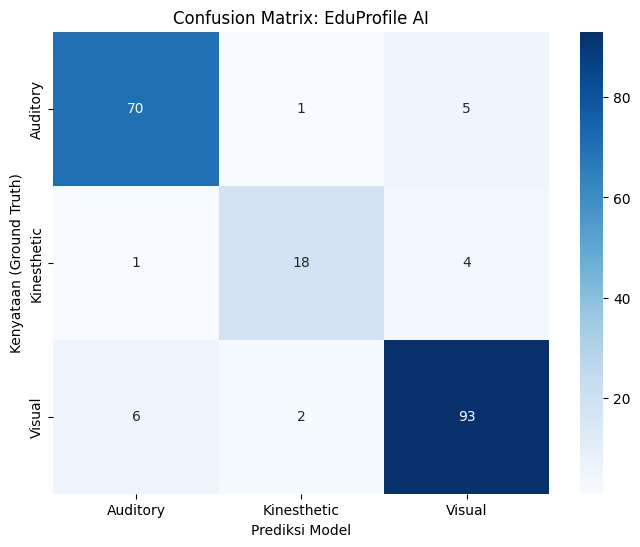

              precision    recall  f1-score   support

    Auditory       0.91      0.92      0.92        76
 Kinesthetic       0.86      0.78      0.82        23
      Visual       0.91      0.92      0.92       101

    accuracy                           0.91       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.90      0.91      0.90       200



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prediksi data testing
y_pred = model.predict([X_nlp_test, X_habit_test])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Buat Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Ground Truth)')
plt.title('Confusion Matrix: EduProfile AI')
plt.show()

# 4. Lihat laporan detail per kelas
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

In [39]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, BertModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model_pt = BertModel.from_pretrained(MODEL_NAME).to(device)
target_labels = {0: 'Auditory', 1: 'Kinesthetic', 2: 'Visual'}

def extract_single_text_feature(text_input):
    # Tokenisasi
    encoded = tokenizer(
        [text_input], # Dibungkus list karena BERT menerima batch
        padding='max_length',
        truncation=True,
        max_length=64,
        return_tensors='pt'
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = bert_model_pt(**encoded)
        pooled_feature = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        
    return pooled_feature

def predict_learning_style(text_reflection, habit_features):
    nlp_input = extract_single_text_feature(text_reflection) 
    habit_input = np.array(habit_features).reshape(1, -1)
    prediction_proba = model.predict(x=[nlp_input, habit_input], verbose=0)
    predicted_class_idx = np.argmax(prediction_proba, axis=1)[0]
    predicted_label = target_labels[predicted_class_idx]
    confidence = prediction_proba[0][predicted_class_idx] * 100
    
    return predicted_label, confidence, prediction_proba[0]



# Simulasi input data 
contoh_teks_user = "Maybe in that deep, dark recess of my soul, I just want to be able to dream again."

# 8 fitur habbit dimulai dari ('EduTech', 'DeviceUsage', 'Resources','Discussions', 'CourseParticipation', 'EmotionEngagement','PhysicalActivity', 'Extracurricular')
contoh_habit_user = [0.45, 0.30, 0.50, 0.90, 0.95, 0.80, 0.40, 0.35] 

# Jalankan fungsi prediksi
gaya_belajar, tingkat_keyakinan, semua_probabilitas = predict_learning_style(contoh_teks_user, contoh_habit_user)

print("============ HASIL PREDIKSI AI ============")
print(f"Kalimat Refleksi : '{contoh_teks_user}'")
print(f"Prediksi Gaya Belajar : {gaya_belajar}")
print(f"Tingkat Keyakinan AI  : {tingkat_keyakinan:.2f}%")
print("-------------------------------------------")
print(f"Detail Probabilitas  :")
print(f" - Auditory    : {semua_probabilitas[0]*100:.2f}%")
print(f" - Kinesthetic : {semua_probabilitas[1]*100:.2f}%")
print(f" - Visual      : {semua_probabilitas[2]*100:.2f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


============ HASIL PREDIKSI AI ============
Kalimat Refleksi : 'Maybe in that deep, dark recess of my soul, I just want to be able to dream again.'
Prediksi Gaya Belajar : Auditory
Tingkat Keyakinan AI  : 100.00%
-------------------------------------------
Detail Probabilitas  :
 - Auditory    : 100.00%
 - Kinesthetic : 0.00%
 - Visual      : 0.00%


In [40]:
# Menyimpan model utuh ke dalam file format .keras
NAMA_FILE_MODEL = 'eduprofile_multimodal_v1.keras'

model.save(NAMA_FILE_MODEL)
print(f"Model berhasil diexport dengan nama: {NAMA_FILE_MODEL}")

Model berhasil diexport dengan nama: eduprofile_multimodal_v1.keras
